In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11


In [5]:
PATH_MAIN  = "../data/raw/aa_dataset-tickets-multi-lang-5-2-50-version.csv"
PATH_V4    = "../data/raw/dataset-tickets-multi-lang-4-20k.csv"
PATH_LANG3 = "../data/raw/dataset-tickets-multi-lang3-4k.csv"

df = pd.read_csv(PATH_MAIN)

print(df.shape)
print(df.columns.tolist())
print()
print(df.head(3))

(28587, 16)
['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']

                                             subject  \
0                    Wesentlicher Sicherheitsvorfall   
1                                 Account Disruption   
2  Query About Smart Home System Integration Feat...   

                                                body  \
0  Sehr geehrtes Support-Team,\n\nich möchte eine...   
1  Dear Customer Support Team,\n\nI am writing to...   
2  Dear Customer Support Team,\n\nI hope this mes...   

                                              answer      type  \
0  Vielen Dank für die Meldung des kritischen Sic...  Incident   
1  Thank you for reaching out, <name>. We are awa...  Incident   
2  Thank you for your inquiry. Our products suppo...   Request   

                   queue priority language  version     tag_1       tag_2  \
0      Technical Support     high       d

In [6]:
print("=== dtypes ===")
print(df.dtypes)
print()
print("=== null counts ===")
print(df.isnull().sum())
print()
print("=== duplicates ===", df.duplicated().sum())

=== dtypes ===
subject     object
body        object
answer      object
type        object
queue       object
priority    object
language    object
version      int64
tag_1       object
tag_2       object
tag_3       object
tag_4       object
tag_5       object
tag_6       object
tag_7       object
tag_8       object
dtype: object

=== null counts ===
subject      3838
body            0
answer          7
type            0
queue           0
priority        0
language        0
version         0
tag_1           0
tag_2          13
tag_3         136
tag_4        3058
tag_5       14042
tag_6       22713
tag_7       26547
tag_8       28022
dtype: int64

=== duplicates === 0


In [7]:
df["subject"] = df["subject"].fillna("")

df = df.dropna(subset=["answer"]).reset_index(drop=True)

tag_cols = [c for c in df.columns if c.startswith("tag_")]
df[tag_cols] = df[tag_cols].fillna("")

print("정제 후 shape:", df.shape)
print("null 잔여:")
print(df.isnull().sum())

정제 후 shape: (28580, 16)
null 잔여:
subject     0
body        0
answer      0
type        0
queue       0
priority    0
language    0
version     0
tag_1       0
tag_2       0
tag_3       0
tag_4       0
tag_5       0
tag_6       0
tag_7       0
tag_8       0
dtype: int64


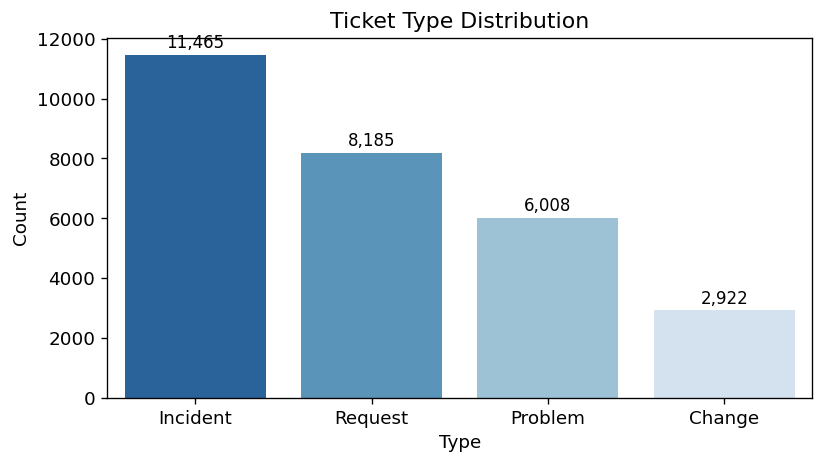

In [10]:
order_type = df["type"].value_counts().index

fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=df, x="type", order=order_type, palette="Blues_r", ax=ax)
ax.set_title("Ticket Type Distribution")
ax.set_xlabel("Type")
ax.set_ylabel("Count")
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 100,
        f"{int(bar.get_height()):,}",
        ha="center", va="bottom", fontsize=10
    )
plt.tight_layout()
plt.savefig("../outputs/figures/01_type_distribution.png")
plt.show()

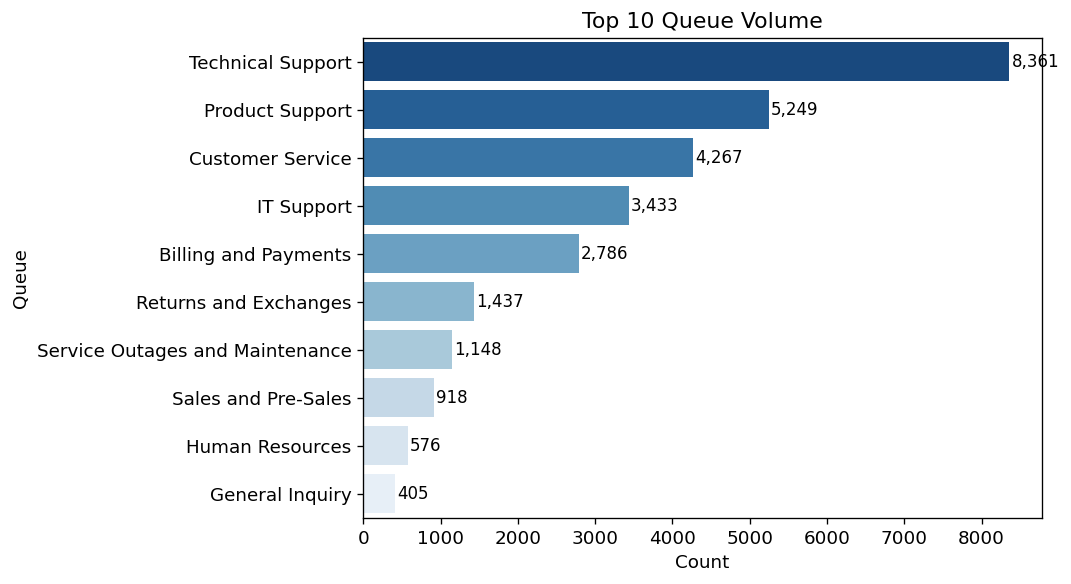

In [12]:
top_queues = df["queue"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top_queues.values, y=top_queues.index, palette="Blues_r", ax=ax)
ax.set_title("Top 10 Queue Volume")
ax.set_xlabel("Count")
ax.set_ylabel("Queue")
for i, v in enumerate(top_queues.values):
    ax.text(v + 30, i, f"{v:,}", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("../outputs/figures/01_queue_top10.png")
plt.show()

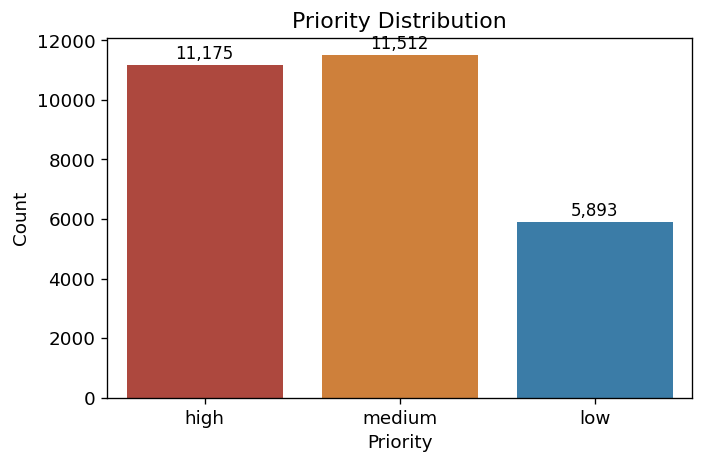

In [13]:
priority_order = ["high", "medium", "low"]
palette_map = {"high": "#c0392b", "medium": "#e67e22", "low": "#2980b9"}

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x="priority", order=priority_order, palette=palette_map, ax=ax)
ax.set_title("Priority Distribution")
ax.set_xlabel("Priority")
ax.set_ylabel("Count")
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 80,
        f"{int(bar.get_height()):,}",
        ha="center", va="bottom", fontsize=10
    )
plt.tight_layout()
plt.savefig("../outputs/figures/01_priority_distribution.png")
plt.show()

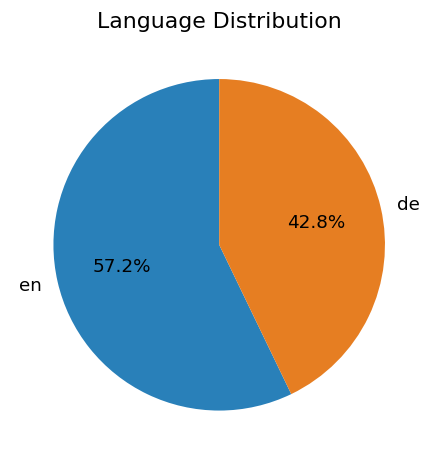

In [14]:
lang_counts = df["language"].value_counts()

fig, ax = plt.subplots(figsize=(5, 4))
ax.pie(
    lang_counts.values,
    labels=lang_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#2980b9", "#e67e22"]
)
ax.set_title("Language Distribution")
plt.tight_layout()
plt.savefig("../outputs/figures/01_language_distribution.png")
plt.show()

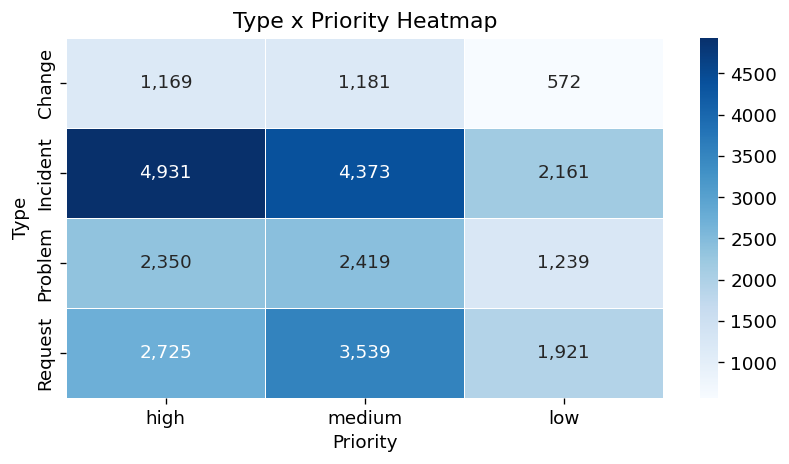

In [15]:
cross = pd.crosstab(df["type"], df["priority"])[priority_order]

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    cross,
    annot=True,
    fmt=",",
    cmap="Blues",
    linewidths=0.5,
    ax=ax
)
ax.set_title("Type x Priority Heatmap")
ax.set_xlabel("Priority")
ax.set_ylabel("Type")
plt.tight_layout()
plt.savefig("../outputs/figures/01_type_priority_heatmap.png")
plt.show()

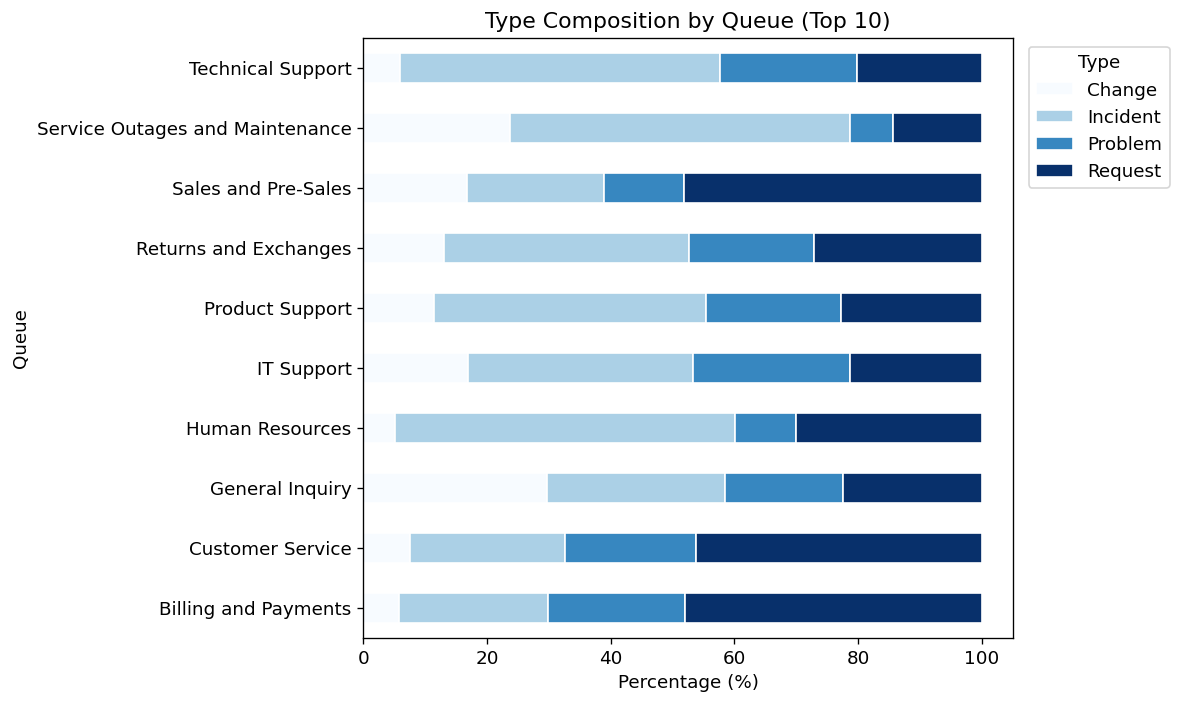

In [16]:
top10_q = df["queue"].value_counts().head(10).index
df_top = df[df["queue"].isin(top10_q)]

cross_q = pd.crosstab(df_top["queue"], df_top["type"], normalize="index") * 100

fig, ax = plt.subplots(figsize=(10, 6))
cross_q.plot(kind="barh", stacked=True, ax=ax, colormap="Blues", edgecolor="white")
ax.set_title("Type Composition by Queue (Top 10)")
ax.set_xlabel("Percentage (%)")
ax.set_ylabel("Queue")
ax.legend(title="Type", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../outputs/figures/01_queue_type_stack.png")
plt.show()

In [18]:
df.to_csv("../data/processed/tickets_clean.csv", index=False)
print("saved -> data/processed/tickets_clean.csv")
print("final shape:", df.shape)

saved -> data/processed/tickets_clean.csv
final shape: (28580, 16)
